# Importações

In [198]:
import pandas as pd
import json
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

#📌 Extracão

In [159]:
with open('TelecomX_Data.json', 'r', encoding='utf-8') as f:
    dados_json = json.load(f)

In [160]:
df_telecom = pd.json_normalize(dados_json)

In [161]:
print(f"O dataset possui {df_telecom.shape[0]} linhas e {df_telecom.shape[1]} colunas.\n")
df_telecom.info()

O dataset possui 7267 linhas e 21 colunas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  inte

In [162]:
display(df_telecom.head())

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformação

In [163]:
df_telecom.columns = [col.split('.')[-1] for col in df_telecom.columns]
print(f"Tamanho original: {df_telecom.shape}")

Tamanho original: (7267, 21)


In [164]:
df_telecom['Churn'] = df_telecom['Churn'].replace('', np.nan)
df_telecom.dropna(subset=['Churn'], inplace=True)
print(f"Tamanho após remover Churn vazio: {df_telecom.shape}")

Tamanho após remover Churn vazio: (7043, 21)


In [165]:
df_telecom['Total'] = pd.to_numeric(df_telecom['Total'], errors='coerce')

In [166]:
nulos = df_telecom['Total'].isnull().sum()
print(f"Valores nulos encontrados na coluna Total após conversão: {nulos}")

Valores nulos encontrados na coluna Total após conversão: 11


In [167]:
df_telecom['Total'] = df_telecom['Total'].fillna(df_telecom['Monthly'])

In [168]:
colunas_para_corrigir = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                         'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

In [169]:
for col in colunas_para_corrigir:
    df_telecom[col] = df_telecom[col].replace({'No internet service': 'No', 'No phone service': 'No'})

In [170]:
print("\n--- BASE LIMPA E PRONTA ---")
df_telecom.info()


--- BASE LIMPA E PRONTA ---
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          

In [171]:
print("\nPrimeiras linhas do DataFrame limpo:")
display(df_telecom.head())


Primeiras linhas do DataFrame limpo:


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [172]:
df_telecom['Contas_Diarias'] = round(df_telecom['Monthly'] / 30, 2)
display(df_telecom[['Monthly', 'Contas_Diarias']].head())

,Monthly,Contas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [173]:
colunas_traduzidas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasao',
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Tem_Parceiro',
    'Dependents': 'Tem_Dependentes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servico_Telefone',
    'MultipleLines': 'Multiplas_Linhas',
    'InternetService': 'Servico_Internet',
    'OnlineSecurity': 'Seguranca_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Protecao_Dispositivo',
    'TechSupport': 'Suporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Filmes',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Fatura_Digital',
    'PaymentMethod': 'Metodo_Pagamento',
    'Monthly': 'Mensalidade',
    'Total': 'Gasto_Total',
    'Contas_Diarias': 'Gasto_Diario'
}

In [174]:
df_telecom.rename(columns=colunas_traduzidas, inplace=True)
mapeamento_binario = {'Yes': 1, 'No': 0}

In [175]:
colunas_binarias = ['Evasao', 'Tem_Parceiro', 'Tem_Dependentes', 'Servico_Telefone',
                    'Multiplas_Linhas', 'Seguranca_Online', 'Backup_Online',
                    'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV',
                    'Streaming_Filmes', 'Fatura_Digital']

for col in colunas_binarias:
    df_telecom[col] = df_telecom[col].map(mapeamento_binario).fillna(df_telecom[col])

In [176]:
df_telecom['Genero'] = df_telecom['Genero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})
df_telecom['Tipo_Contrato'] = df_telecom['Tipo_Contrato'].replace({
    'Month-to-month': 'Mensal',
    'One year': 'Anual',
    'Two year': 'Bienal'
})

In [177]:
display(df_telecom.head())

,ID_Cliente,Evasao,Genero,Idoso,Tem_Parceiro,Tem_Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Mensalidade,Gasto_Total,Gasto_Diario
0,0002-ORFBO,0,Feminino,0,1,1,9,1,0,DSL,...,0,1,1,0,Anual,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensal,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Mensal,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Mensal,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Feminino,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Mensal,1,Mailed check,83.9,267.40,2.80


#📊 Carga e análise

In [178]:
print("--- Estatísticas das Variáveis Numéricas ---")
display(df_telecom[['Meses_Contrato', 'Mensalidade', 'Gasto_Total', 'Gasto_Diario']].describe())

--- Estatísticas das Variáveis Numéricas ---


,Meses_Contrato,Mensalidade,Gasto_Total,Gasto_Diario
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.798992,2.158675
std,24.559481,30.090047,2266.730170,1.003088
min,0.000000,18.250000,18.800000,0.610000
25%,9.000000,35.500000,398.550000,1.180000
50%,29.000000,70.350000,1394.550000,2.340000
75%,55.000000,89.850000,3786.600000,2.990000
max,72.000000,118.750000,8684.800000,3.960000


In [179]:
taxa_evasao = df_telecom['Evasao'].value_counts(normalize=True) * 100
print("\n--- Distribuição da Variável Alvo (Evasão) ---")
print(f"Clientes Ativos (0): {taxa_evasao[0]:.2f}%")
print(f"Clientes que Cancelaram (1): {taxa_evasao[1]:.2f}%")


--- Distribuição da Variável Alvo (Evasão) ---
Clientes Ativos (0): 73.46%
Clientes que Cancelaram (1): 26.54%


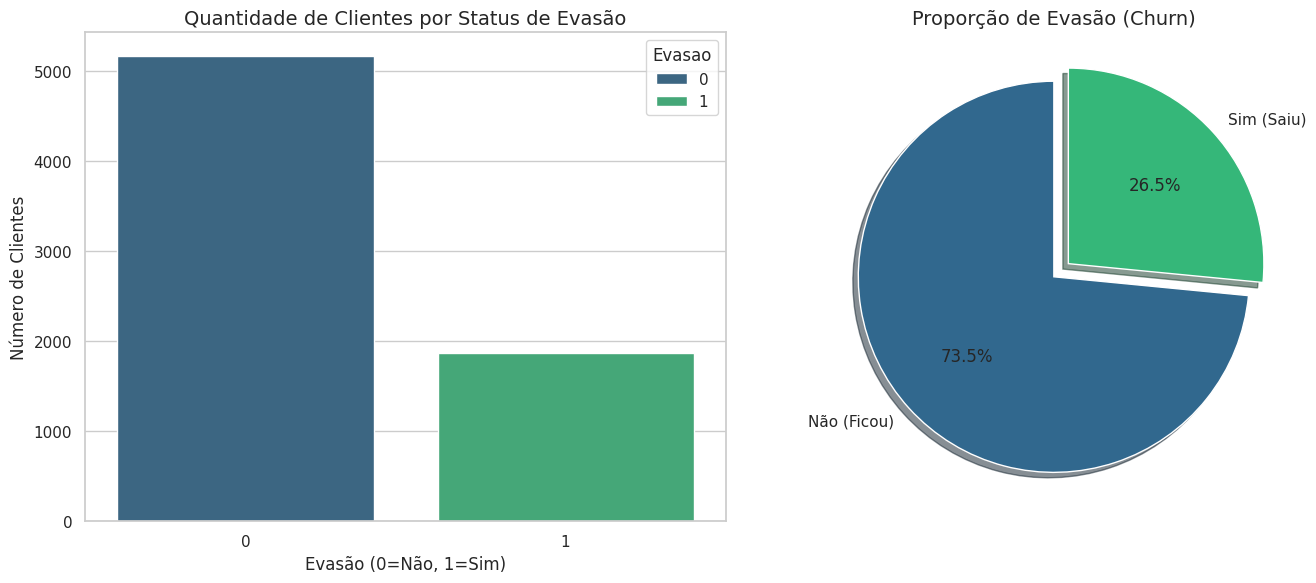

In [180]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de Barras (Quantidade absoluta)
sns.countplot(data=df_telecom, x='Evasao', palette='viridis', hue='Evasao', ax=ax[0])
ax[0].set_title('Quantidade de Clientes por Status de Evasão', fontsize=14)
ax[0].set_xlabel('Evasão (0=Não, 1=Sim)', fontsize=12)
ax[0].set_ylabel('Número de Clientes', fontsize=12)

# 2. Gráfico de Pizza (Proporção percentual)
evasao_counts = df_telecom['Evasao'].value_counts()
ax[1].pie(evasao_counts, labels=['Não (Ficou)', 'Sim (Saiu)'], autopct='%.1f%%',
          startangle=90, colors=sns.color_palette('viridis', 2), explode=[0, 0.1], shadow=True)
ax[1].set_title('Proporção de Evasão (Churn)', fontsize=14)

plt.tight_layout()
plt.show()

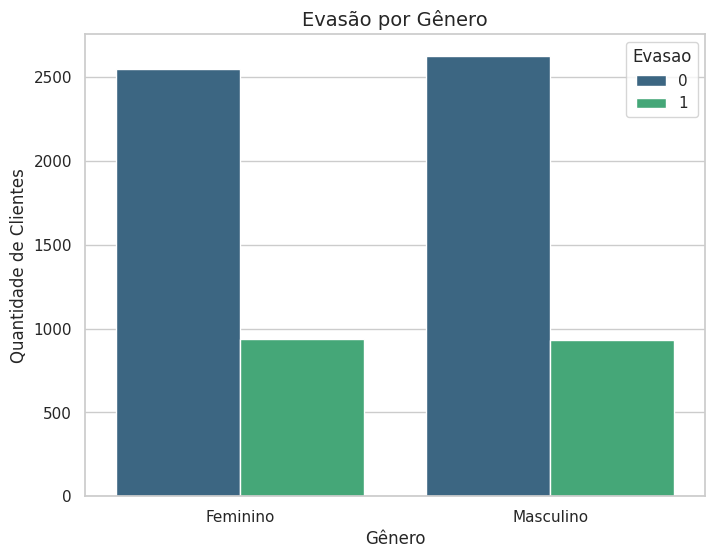

In [181]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_telecom, x='Genero', hue='Evasao', palette='viridis')
plt.title('Evasão por Gênero', fontsize=14)
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Clientes')
plt.show()

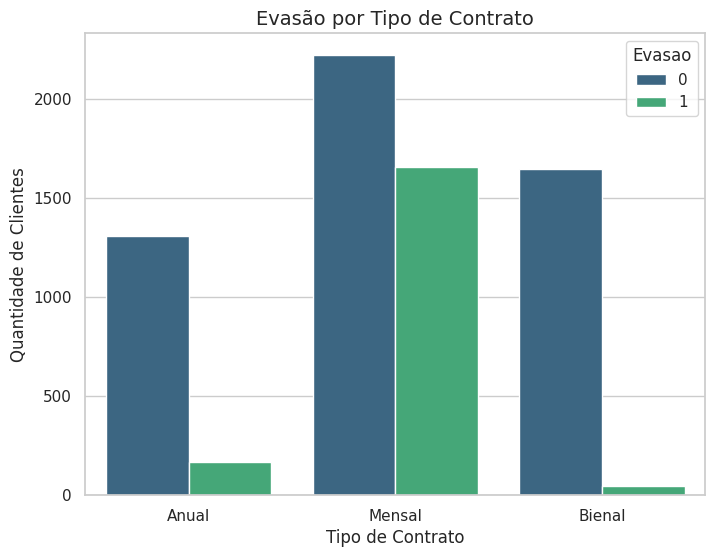

In [182]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_telecom, x='Tipo_Contrato', hue='Evasao', palette='viridis')
plt.title('Evasão por Tipo de Contrato', fontsize=14)
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.show()

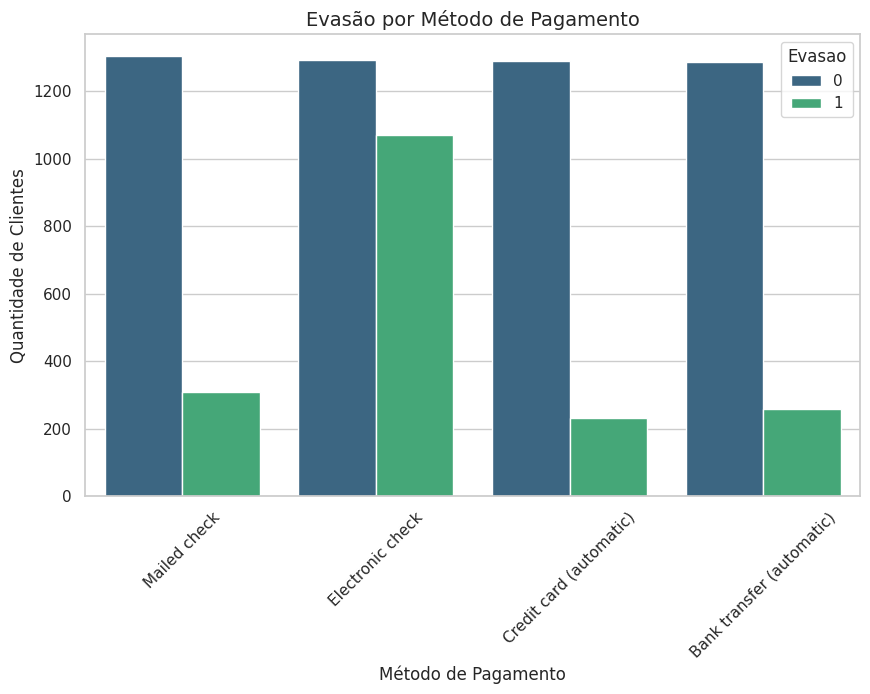

In [183]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_telecom, x='Metodo_Pagamento', hue='Evasao', palette='viridis')
plt.title('Evasão por Método de Pagamento', fontsize=14)
plt.xlabel('Método de Pagamento')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=45)
plt.show()

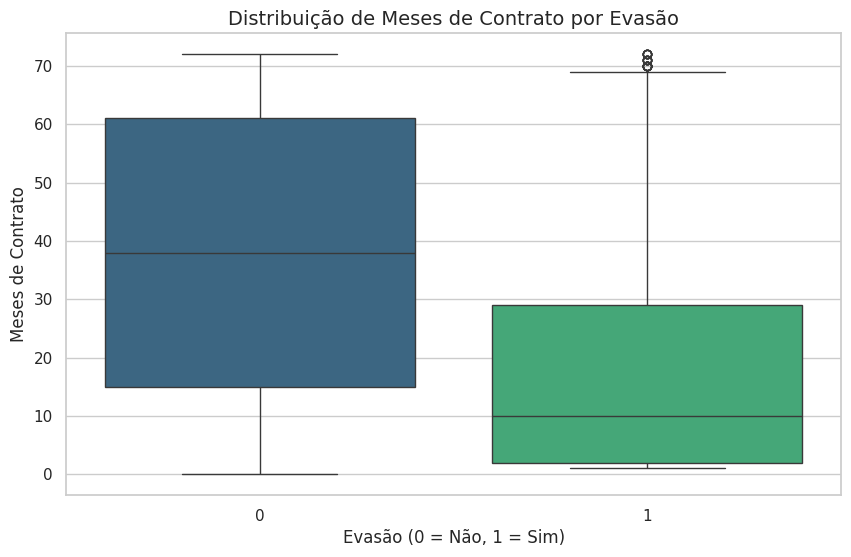

In [184]:
#Meses de Contrato vs. Evasão
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_telecom, x='Evasao', y='Meses_Contrato', palette='viridis', hue='Evasao', legend=False)
plt.title('Distribuição de Meses de Contrato por Evasão', fontsize=14)
plt.xlabel('Evasão (0 = Não, 1 = Sim)')
plt.ylabel('Meses de Contrato')
plt.show()

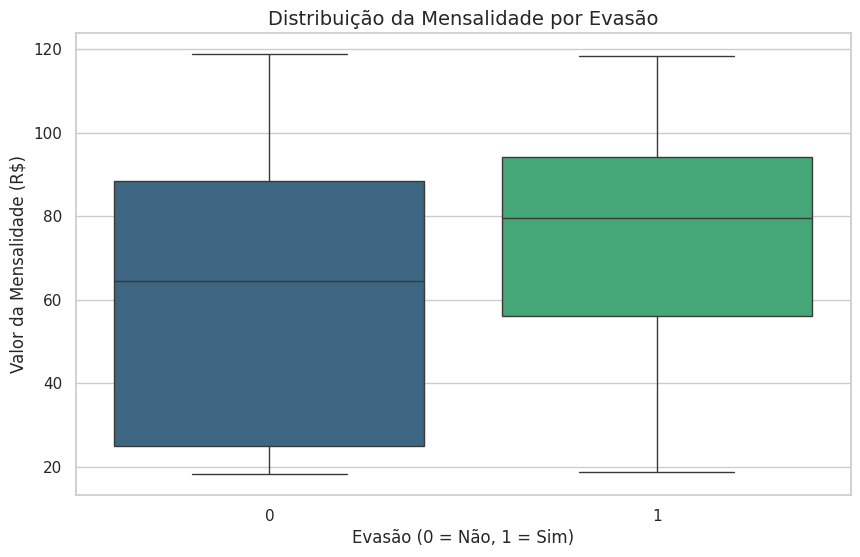

In [185]:
#Mensalidade vs. Evasão
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_telecom, x='Evasao', y='Mensalidade', palette='viridis', hue='Evasao', legend=False)
plt.title('Distribuição da Mensalidade por Evasão', fontsize=14)
plt.xlabel('Evasão (0 = Não, 1 = Sim)')
plt.ylabel('Valor da Mensalidade (R$)')
plt.show()

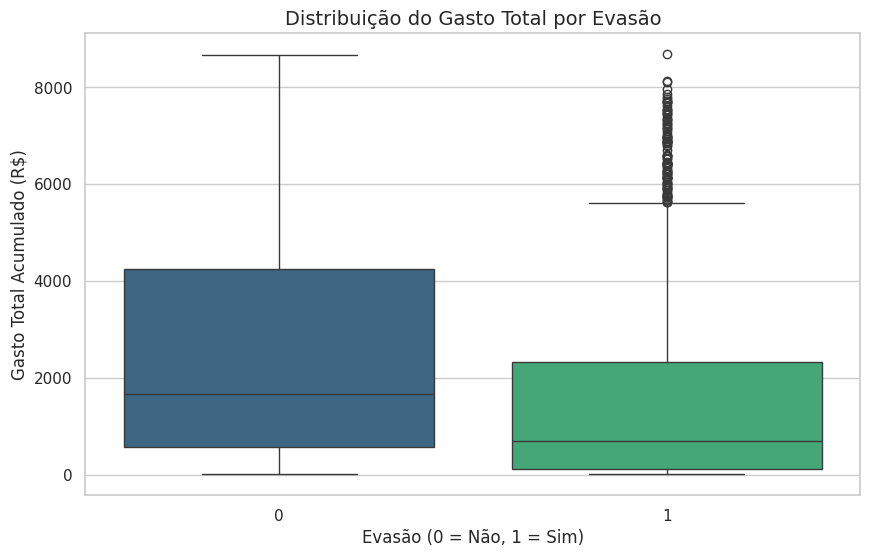

In [186]:
#Gasto Total vs. Evasão
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_telecom, x='Evasao', y='Gasto_Total', palette='viridis', hue='Evasao', legend=False)
plt.title('Distribuição do Gasto Total por Evasão', fontsize=14)
plt.xlabel('Evasão (0 = Não, 1 = Sim)')
plt.ylabel('Gasto Total Acumulado (R$)')
plt.show()

# *🛠️ Preparação dos Dados*

In [187]:
df_telecom.drop(columns=['ID_Cliente'], inplace=True)

print(f"Novo formato do DataFrame: {df_telecom.shape}")
display(df_telecom.head(2))

Novo formato do DataFrame: (7043, 21)


,Evasao,Genero,Idoso,Tem_Parceiro,Tem_Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,Seguranca_Online,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Mensalidade,Gasto_Total,Gasto_Diario
0,0,Feminino,0,1,1,9,1,0,DSL,0,...,0,1,1,0,Anual,1,Mailed check,65.6,593.3,2.19
1,0,Masculino,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Mensal,0,Mailed check,59.9,542.4,2.00


# **🎯 Correlação e Seleção de Variáveis**

In [188]:
colunas_categoricas = ['Genero', 'Servico_Internet', 'Tipo_Contrato', 'Metodo_Pagamento']
df_telecom = pd.get_dummies(df_telecom, columns=colunas_categoricas, drop_first=True)
df_telecom = df_telecom.astype(int)

In [189]:
colunas_numericas = ['Meses_Contrato', 'Mensalidade', 'Gasto_Total', 'Gasto_Diario']

scaler = StandardScaler()
df_telecom[colunas_numericas] = scaler.fit_transform(df_telecom[colunas_numericas])

display(df_telecom.head())

,Evasao,Idoso,Tem_Parceiro,Tem_Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Seguranca_Online,Backup_Online,Protecao_Dispositivo,...,Gasto_Total,Gasto_Diario,Genero_Masculino,Servico_Internet_Fiber optic,Servico_Internet_No,Tipo_Contrato_Bienal,Tipo_Contrato_Mensal,Metodo_Pagamento_Credit card (automatic),Metodo_Pagamento_Electronic check,Metodo_Pagamento_Mailed check
0,0,0,1,1,-0.951682,1,0,0,1,0,...,-0.744002,0.359289,0,0,0,0,0,0,0,1
1,0,0,0,0,-0.951682,1,1,0,0,0,...,-0.766503,0.359289,1,0,0,0,1,0,0,1
2,1,0,0,0,-1.155283,1,0,0,0,1,...,-0.882096,0.359289,1,1,0,0,1,0,1,0
3,1,1,1,0,-0.788800,1,0,0,1,1,...,-0.459871,1.270186,1,1,0,0,1,0,1,0
4,1,1,1,0,-1.196004,1,0,0,0,0,...,-0.887831,0.359289,0,1,0,0,1,0,0,1


🎯 Correlação e Seleção de Variáveis

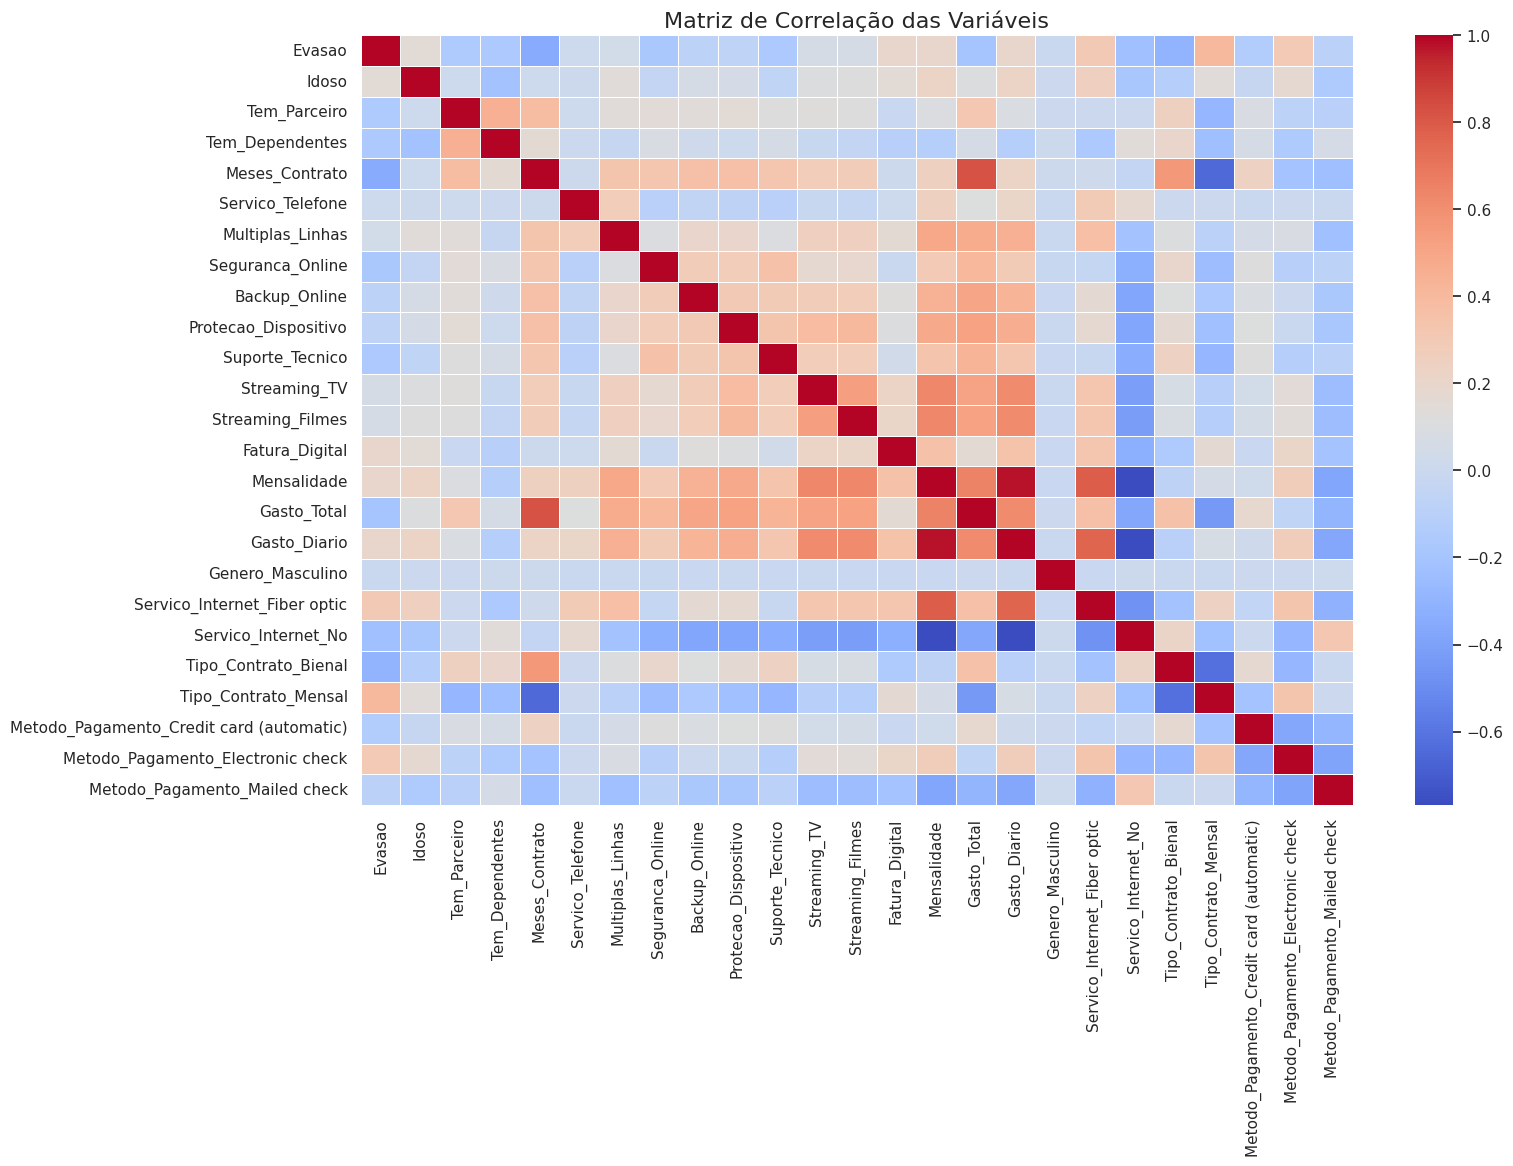

--- Correlação com a Evasão ---
Evasao                                      1.000000
Tipo_Contrato_Mensal                        0.405103
Servico_Internet_Fiber optic                0.308020
Metodo_Pagamento_Electronic check           0.301919
Gasto_Diario                                0.196022
Mensalidade                                 0.193422
Fatura_Digital                              0.191825
Idoso                                       0.150889
Streaming_TV                                0.063228
Streaming_Filmes                            0.061382
Multiplas_Linhas                            0.040102
Servico_Telefone                            0.011942
Genero_Masculino                           -0.008612
Protecao_Dispositivo                       -0.066160
Backup_Online                              -0.082255
Metodo_Pagamento_Mailed check              -0.091683
Metodo_Pagamento_Credit card (automatic)   -0.134302
Tem_Parceiro                               -0.150448
Tem_Dependente

In [190]:
#1. Mapa de Calor da Matriz de Correlação
plt.figure(figsize=(16, 10))
correlacao = df_telecom.corr()

sns.heatmap(correlacao, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis', fontsize=16)
plt.show()

print("--- Correlação com a Evasão ---")
correlacao_evasao = correlacao['Evasao'].sort_values(ascending=False)
print(correlacao_evasao)

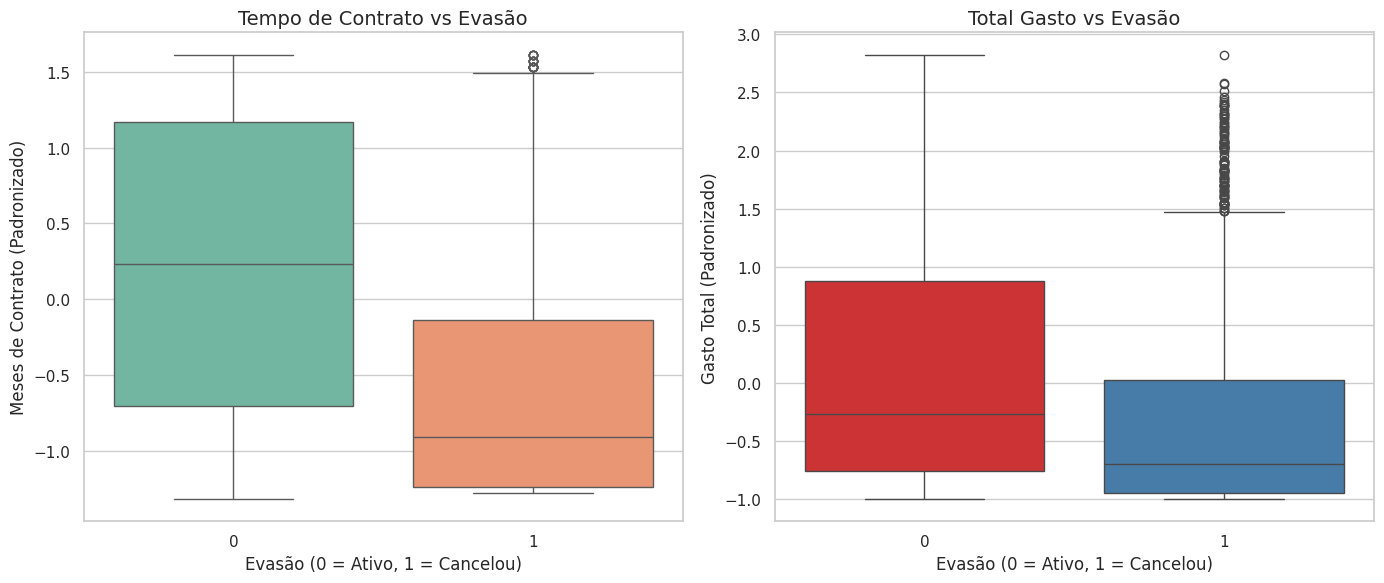

In [191]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='Evasao', y='Meses_Contrato', data=df_telecom, palette='Set2', hue='Evasao', legend=False)
plt.title('Tempo de Contrato vs Evasão', fontsize=14)
plt.xlabel('Evasão (0 = Ativo, 1 = Cancelou)', fontsize=12)
plt.ylabel('Meses de Contrato (Padronizado)', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(x='Evasao', y='Gasto_Total', data=df_telecom, palette='Set1', hue='Evasao', legend=False)
plt.title('Total Gasto vs Evasão', fontsize=14)
plt.xlabel('Evasão (0 = Ativo, 1 = Cancelou)', fontsize=12)
plt.ylabel('Gasto Total (Padronizado)', fontsize=12)

plt.tight_layout()
plt.show()

# **🤖 Modelagem Preditiva**

In [192]:
X = df_telecom.drop('Evasao', axis=1)
y = df_telecom['Evasao']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamanho do Treino: {X_train.shape[0]} linhas")
print(f"Tamanho do Teste: {X_test.shape[0]} linhas")

Tamanho do Treino: 4930 linhas
Tamanho do Teste: 2113 linhas


--- MÉTRICAS: REGRESSÃO LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1552
           1       0.64      0.54      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



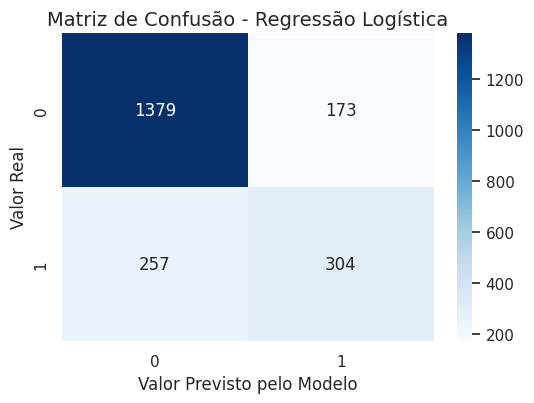

In [193]:
# Modelo 1: Regressão Logistica

modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)
y_pred_train_lr = modelo_lr.predict(X_train)

print("--- MÉTRICAS: REGRESSÃO LOGÍSTICA ---")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Regressão Logística', fontsize=14)
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Valor Previsto pelo Modelo', fontsize=12)
plt.show()

--- MÉTRICAS: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1552
           1       0.64      0.52      0.58       561

    accuracy                           0.80      2113
   macro avg       0.74      0.71      0.72      2113
weighted avg       0.79      0.80      0.79      2113



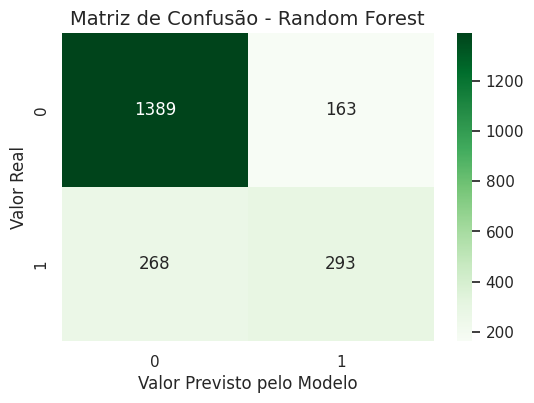

In [194]:
# Modelo 2: Random Forest

modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=8)
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_pred_train_rf = modelo_rf.predict(X_train)

print("--- MÉTRICAS: RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - Random Forest', fontsize=14)
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Valor Previsto pelo Modelo', fontsize=12)
plt.show()

In [195]:
# Comparação de Desempenho
print("=== Análise de Overfitting / Underfitting ===")
print(f"Regressão Logística - Acurácia no Treino: {accuracy_score(y_train, y_pred_train_lr):.4f}")
print(f"Regressão Logística - Acurácia no Teste:  {accuracy_score(y_test, y_pred_lr):.4f}")
print("-" * 50)
print(f"Random Forest       - Acurácia no Treino: {accuracy_score(y_train, y_pred_train_rf):.4f}")
print(f"Random Forest       - Acurácia no Teste:  {accuracy_score(y_test, y_pred_rf):.4f}")

=== Análise de Overfitting / Underfitting ===
Regressão Logística - Acurácia no Treino: 0.8101
Regressão Logística - Acurácia no Teste:  0.7965
--------------------------------------------------
Random Forest       - Acurácia no Treino: 0.8389
Random Forest       - Acurácia no Teste:  0.7960


### 📊 Análise dos Modelos Criados


Avaliando as métricas, ambos os modelos tiveram um desempenho geral  muito semelhante, em torno de 80%. Ademais, ao lidar com evasão, a métrica de **Recall** para a classe `1` é crucial, pois queremos identificar o máximo possível de clientes em risco. A Regressão Logística geralmente apresenta um equilíbrio levemente melhor entre Recall e Precisão neste tipo de dataset sem a necessidade de configurações complexas.

* **Regressão Logística:** As acurácias de treino e teste ficaram extremamente próximas, provando que o modelo generalizou muito bem e aprendeu as tendências corretamente.
* **Random Forest:** O modelo Random Forest tem uma tendência natural ao *overfitting* . Para mitigar isso, utilizamos o parâmetro `max_depth=8`.

 Devido à simplicidade, alta interpretabilidade e ótima capacidade de generalização sem overfitting, a **Regressão Logística** seria o modelo escolhido para produção nesta etapa inicial.

# **📄Análise de Importância das Variáveis**

Para melhor entendimento de como cada modelo toma sua decisão, será analisado quais características dos clientes têm maior peso na hora de prever a evasão.

* **Regressão Logística:** Analisaremos os coeficientes. Valores positivos altos -> variáveis que empurram o cliente para o cancelamento , enquanto valores negativos altos -> variáveis que retêm o cliente.
* **Random Forest:** Analisaremos o cálculo de importância. Ele nos mostra quais variáveis foram mais usadas para separar os clientes com e sem fidelidade

/tmp/ipykernel_451/2364832531.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variavel', data=importancia_lr, palette='coolwarm')


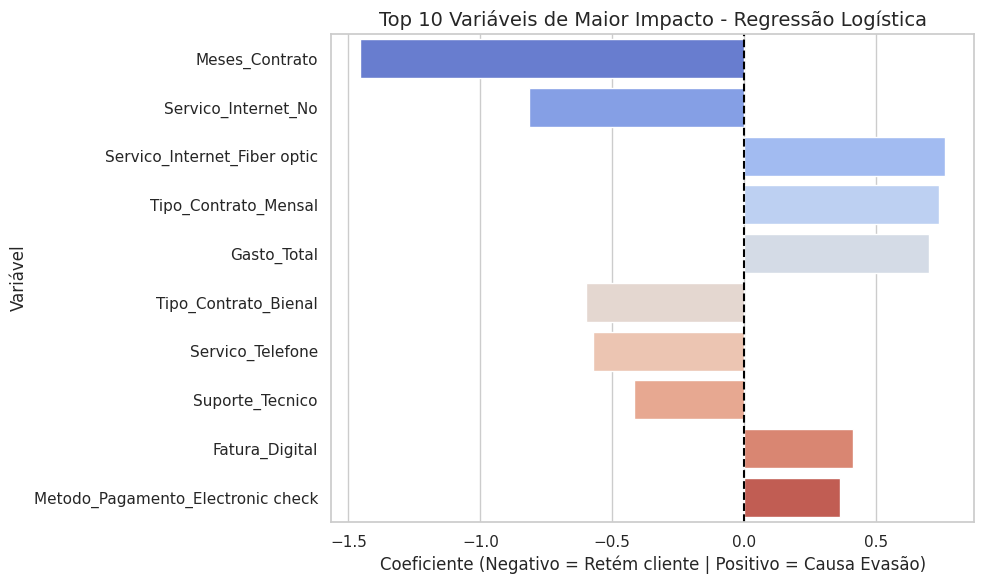

In [196]:
importancia_lr = pd.DataFrame({
    'Variavel': X_train.columns,
    'Coeficiente': modelo_lr.coef_[0]
})

importancia_lr['Absoluto'] = importancia_lr['Coeficiente'].abs()
importancia_lr = importancia_lr.sort_values(by='Absoluto', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficiente', y='Variavel', data=importancia_lr, palette='coolwarm')
plt.title('Top 10 Variáveis de Maior Impacto - Regressão Logística', fontsize=14)
plt.xlabel('Coeficiente (Negativo = Retém cliente | Positivo = Causa Evasão)', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

/tmp/ipykernel_451/205956116.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variavel', data=importancia_rf, palette='viridis')


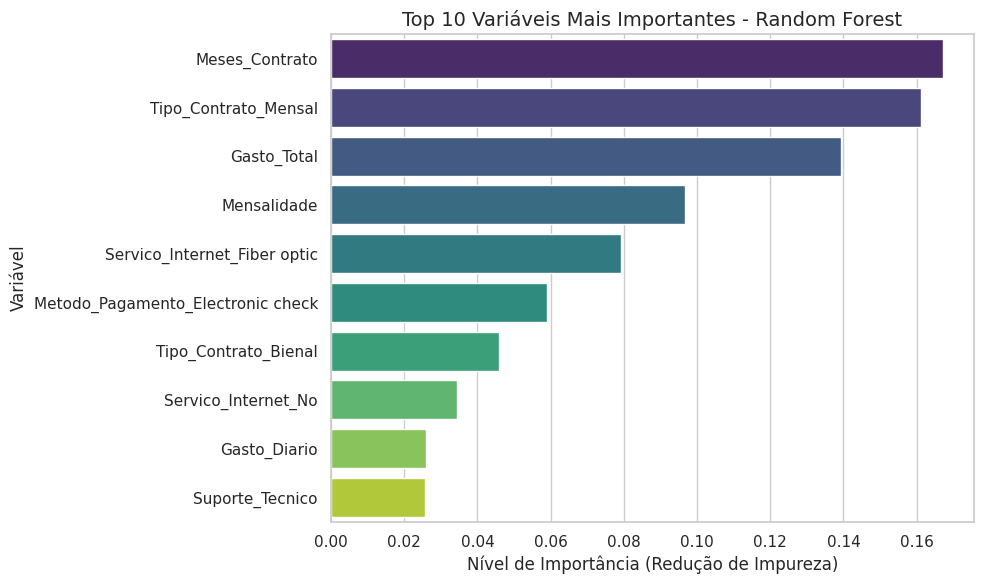

In [197]:
importancia_rf = pd.DataFrame({
    'Variavel': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancia_rf = importancia_rf.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variavel', data=importancia_rf, palette='viridis')
plt.title('Top 10 Variáveis Mais Importantes - Random Forest', fontsize=14)
plt.xlabel('Nível de Importância (Redução de Impureza)', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.tight_layout()
plt.show()

### Conclusão da Análise

**Regressão Logística:**
Através dos coeficientes, observamos que o **Tempo de Contrato** possui um coeficiente fortemente negativo. Por outro lado, variáveis como **Contrato Mensal** e **Internet Fibra Óptica** possuem coeficientes positivos altos.

**Random Forest :**
O Random Forest confirmou as descobertas da Regressão Logística, colocando o **Tempo de Contrato**, **Gasto Total** e **Mensalidade** no topo do ranking de importância.

**Ação Estratégica:** Como o tempo de contrato e contratos mensais são os maiores causadores de evasão, a empresa deve focar seus esforços de marketing em **converter clientes de planos mensais para planos anuais**.

# 📑 Relatório

##  Desempenho dos Modelos Preditivos
Durante a etapa de modelagem, foi desenvolvido e comparado dois algoritmos para prever a evasão de clientes: **Regressão Logística** e **Random Forest**.

* **Regressão Logística:** Demonstrou um desempenho sólido. Por ser um modelo linear, permitiu uma interpretação clara do peso de cada variável na decisão de evasão.
* **Random Forest:** Apresentou acurácia semelhante, mas exigiu ajustes de hiperparâmetros para evitar o overfitting.

**Conclusão:** A **Regressão Logística** se mostrou a opção mais viável e balanceada para este cenário inicial, garantindo boa explicabilidade e facilidade de implementação.


## Fatores que Influenciam a Evasão
A análise de importância das variáveis de ambos os modelos revelou padrões sobre o que motiva um cliente a cancelar o serviço. São eles:
1. **Tipo de Contrato:** Clientes com contratos mensais não possuem barreiras de saída (multas ou fidelidade).
2. **Tempo de Contrato:** O risco de churn é altíssimo nos primeiros 6 meses.
3. **Serviço de Internet :** após analise foi obtido indicadores que o serviço de fibra possui problemas técnicos (instabilidade) ou que o preço cobrado está muito acima da percepção de valor do cliente devido a aderencia de cancelamento.
4. **Fatores Financeiros:** Mensalidades muito altas e o uso de "Cheque Eletrônico" (Electronic check) como método de pagamento estão fortemente associados à evasão.
5. **Falta de Serviços Adicionais:** Clientes que **não** possuem Suporte Técnico (TechSupport) ou Segurança Online (OnlineSecurity) abandonam o serviço mais facilmente.


## Estratégias de Retenção Propostas
Com base no diagnóstico dos modelos preditivos, é proposto as seguintes ações estratégicas:

* **Conversão de Contratos Mensais**

  Criar campanhas agressivas de marketing focadas na base de clientes com contrato mensal, oferecendo **descontos significativos ou upgrade gratuito de velocidade** para que eles migrem para contratos de 1 ou 2 anos.

* **Programa de *Onboarding* e Boas-vindas**

  Como a evasão ocorre logo no início da jornada do cliente, a empresa deve implementar um time de "Sucesso do Cliente" para acompanhar de perto os novos usuários nos primeiros 3 a 6 meses.

* **Investigação e Ação sobre a Fibra Óptica**
  É urgente que a equipe técnica e de qualidade investigue a infraestrutura da Fibra Óptica.

* **Débito Automático**
  Oferecer pequenos descontos para clientes que cadastrarem o pagamento em Débito em Conta ou Cartão de Crédito Automático, reduzindo a evasão por inadimplência ou atrito de pagamento.

* **Combos de Proteção e Suporte**
  Oferecer pacotes que incluam "Suporte Técnico Premium" ou "Segurança Online" a um custo muito baixo, ou até gratuitamente nos primeiros meses.